In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys

from distribution import Distribution

In [3]:
# p(x)

def p(
    x: float | np.ndarray, A: float, Nsat: float, a: float, b: float, c: float
) -> float | np.ndarray:
    """
    Number density profile of satellite galaxies

    Parameters
    ----------
    x : float | ndarray
        Radius in units of virial radius; x = r / r_virial
    A : float
        Normalisation
    Nsat : float
        Average number of satellites
    a : float
        Small-scale slope
    b : float
        Transition scale
    c : float
        Steepness of exponential drop-off

    Returns
    -------
    float | ndarray
        Same type and shape as x. Number density of satellite galaxies
        at given radius x.
    """
    
    return 4*np.pi*A*(x/b)**(a-1) * np.exp(-(x/b)**c)

def f(
        x: float | np.ndarray, beta: float
    ) -> float | np.ndarray:
    return beta*np.exp(-beta*x)




In [12]:
# Values from the hand-in
a = 2.4
b = 0.25
c = 1.6
A=9.19
Nsat=100
x_vals = np.geomspace(1e-5, 5, 500)
y_vals = p(x_vals, A=A, Nsat=Nsat, a=a, b=b, c=c)
f_vals = 65*f(x_vals, beta=1)


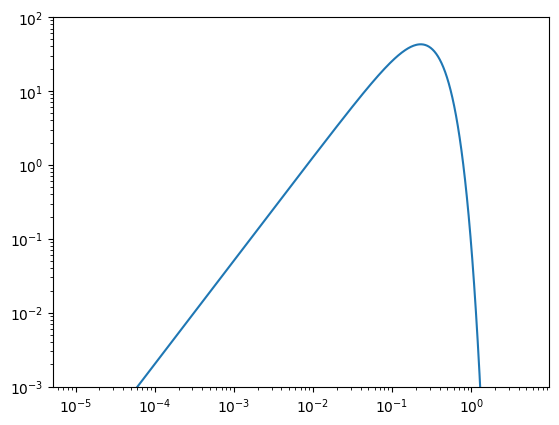

In [17]:
plt.plot(x_vals, y_vals)
#plt.plot(x_vals, f_vals)
#plt.vlines(b, 0, np.log(10000))
#plt.xscale("log")
plt.loglog()
plt.ylim(1e-3, 1e2)
plt.show()

In [6]:
dist = Distribution(p, 0, 5, (9.19, Nsat, a, b, c))

In [7]:
samples = dist.rejection(10000)

/home/milan/Desktop/NURa_handin_2/rng.py:42: RuntimeWarning: overflow encountered in scalar add
  x = int(self.XOR1() + self.XOR2()) # add the two XOR methods
